In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import requests
import io

In [ ]:
def fetch_grch38_annotations():
    """Fetches GRCh38 gene annotations from Ensembl BioMart."""
    print("Fetching GRCh38 gene annotations...")
    biomart_xml = """<?xml version="1.0" encoding="UTF-8"?>
    <!DOCTYPE Query>
    <Query virtualSchemaName="default" formatter="TSV" header="1" uniqueRows="1" count="" datasetConfigVersion="0.6">
        <Dataset name="hsapiens_gene_ensembl" interface="default">
            <Attribute name="ensembl_gene_id" />
            <Attribute name="hgnc_symbol" />
            <Attribute name="start_position" />
            <Attribute name="end_position" />
        </Dataset>
    </Query>"""

    url = "http://www.ensembl.org/biomart/martservice"
    response = requests.post(url, data={'query': biomart_xml})
    response.raise_for_status()
    
    df = pd.read_csv(io.StringIO(response.text), sep='\t')
    df.columns = ['Ensembl_ID', 'Gene_Symbol', 'Start', 'End']
    df.to_csv('GRCH38_annotations.csv')
    return df

def generate_forward_unimodal():
    # 1. Fetch and clean real GRCh38 Data
    grch38_df = fetch_grch38_annotations()
    grch38_df = grch38_df.dropna(subset=['Gene_Symbol'])
    grch38_df = grch38_df[grch38_df['Gene_Symbol'] != '']
    grch38_df['Gene_Length'] = (grch38_df['End'] - grch38_df['Start']).abs()
    grch38_df = grch38_df.sort_values('Gene_Length', ascending=False).drop_duplicates('Gene_Symbol')

    # 2. Sample exactly 50,000 genes
    target_n = 50000
    n_genes_to_sample = min(target_n, len(grch38_df))
    df_sampled = grch38_df.sample(n=n_genes_to_sample, random_state=42).copy()
    df_sampled = df_sampled[['Ensembl_ID', 'Gene_Symbol', 'Gene_Length']].reset_index(drop=True)

    np.random.seed(42)
    depths = [20, 30, 40, 50]
    
    # 3. FORWARD FPKM GENERATION
    # Start with a standard log-normal distribution with a high median
    base_fpkm = np.random.lognormal(mean=np.log(30), sigma=1.0, size=n_genes_to_sample)
    
    # Apply a gentle length-weighting factor to bridge the bimodal length gap.
    # We use 3000bp as the "standard" mRNA median length.
    # If you look at real RNA-seq datasets, you will consistently find a strong inverse 
    # correlation between transcript length and normalized expression (FPKM/TPM).
    length_correction = (3000 / df_sampled['Gene_Length']) ** 0.5
    
    # Add a base minimum (+ 5) to strictly eliminate extreme lows and zeros
    df_sampled['Random_FPKM'] = (base_fpkm * length_correction) + 1

    # 4. Calculate pseudo-raw counts using exact formula
    for r in depths:
        col_name = f'Counts_{r}M'
        # Formula: ((FPKM * Length) / R)
        df_sampled[col_name] = ((df_sampled['Random_FPKM'] * df_sampled['Gene_Length']) / r).round().astype(int)

    # 5. Save output
    output_file = "grch38_pseudoRawCounts_forward_unimodal.csv"
    df_sampled.to_csv(output_file, index=False)
    print(f"\nSaved {n_genes_to_sample} genes to {output_file}")

In [4]:
generate_forward_unimodal()

Fetching GRCh38 gene annotations...

Saved 41365 genes to grch38_pseudoRawCounts_forward_unimodal.csv


In [5]:
df_sampled = pd.read_csv("grch38_pseudoRawCounts_forward_unimodal.csv", header = 0)

In [6]:
df_sampled.head()

,Ensembl_ID,Gene_Symbol,Gene_Length,Random_FPKM,Counts_20M,Counts_30M,Counts_40M,Counts_50M
0,ENSG00000165698,SPACA9,12174,25.472901,15505,10337,7753,6202
1,ENSG00000242688,RN7SL304P,300,83.617839,1254,836,627,502
2,ENSG00000213169,RPL8P4,761,114.835341,4369,2913,2185,1748
3,ENSG00000223158,RNY1P3,117,697.678509,4081,2721,2041,1633
4,ENSG00000272143,FGF14-AS2,1129,39.693979,2241,1494,1120,896


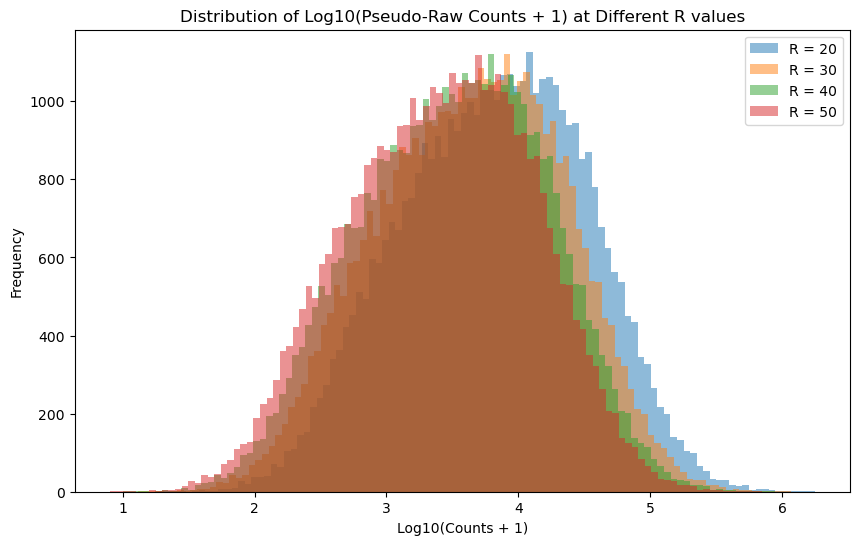

In [7]:
# 5. Plotting the distributions
plt.figure(figsize=(10, 6))
for r in [20,30,40,50]:
    # Using log10(counts + 1) for better visualization of the spread
    log_counts = np.log10(df_sampled[f'Counts_{r}M'] + 1)
    plt.hist(log_counts, bins=100, alpha=0.5, label=f'R = {r}')

plt.title('Distribution of Log10(Pseudo-Raw Counts + 1) at Different R values')
plt.xlabel('Log10(Counts + 1)')
plt.ylabel('Frequency')
plt.legend()
plt.show()